In [1]:
import matplotlib.pyplot as plt
import r2l
import gymnasium as gym 
import torch
import rl_utils

In [2]:
actor_lr = 1e-3
critic_lr = 1e-2
num_episodes = 500
hidden_dim = 128
gamma = 0.98
lmbda = 0.95
epochs = 10
eps = 0.2
device = r2l.get_gpu()

In [3]:
env_name = 'CartPole-v0'
env = gym.make(env_name)
env.reset(seed=0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = r2l.PPO(state_dim, hidden_dim, action_dim, actor_lr,critic_lr, lmbda, epochs, eps, gamma, device)

return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)

/home/austin/.conda/envs/r2l/lib/python3.12/site-packages/gymnasium/envs/registration.py:519: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
Iteration 0:   0%|          | 0/50 [00:00<?, ?it/s]/home/austin/workspace/d2l/src/r2l.py:1435: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  states = torch.tensor(transition_dict["states"], dtype=torch.float).to(
Iteration 9: 100%|██████████| 50/50 [00:00<00:00, 56.23it/s, episode=500, return=200.000]


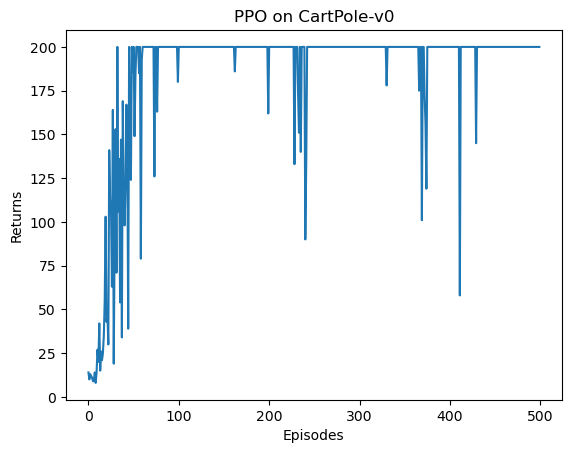

In [4]:
episodes_lsit = list(range(len(return_list)))
plt.plot(episodes_lsit, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()

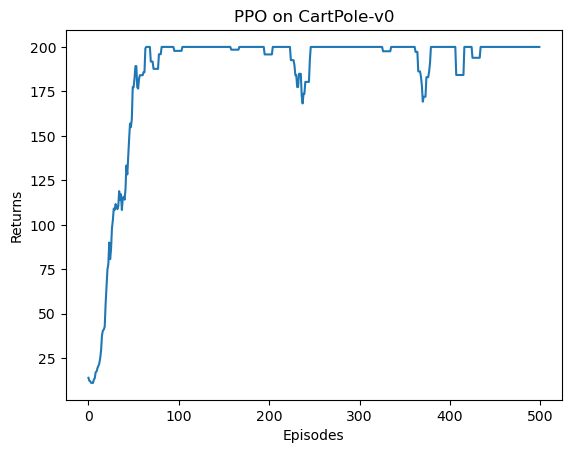

In [5]:
moving_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_lsit, moving_return)
plt.xlabel("Episodes")
plt.ylabel("Returns")
plt.title("PPO on {}".format(env_name))
plt.show()

# PPO 连续情况

In [2]:
actor_lr = 1e-4
critic_lr = 5e-3
num_episodes = 2000
hidden_dim = 128
gamma = 0.9
lmbda = 0.9
epochs = 10
eps = 0.2
device = r2l.get_gpu()


In [3]:
env_name = 'Pendulum-v1'
env = gym.make(env_name)
env.reset(seed=0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
agent = r2l.PPOCountinuous(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda, epochs, eps, gamma, device)
return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)


Iteration 0:   0%|          | 0/200 [00:00<?, ?it/s]/home/austin/workspace/d2l/src/r2l.py:1523: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  states = torch.tensor(transition_dict["states"], dtype=torch.float).to(
Iteration 9: 100%|██████████| 200/200 [00:03<00:00, 50.21it/s, episode=2000, return=-323.016]


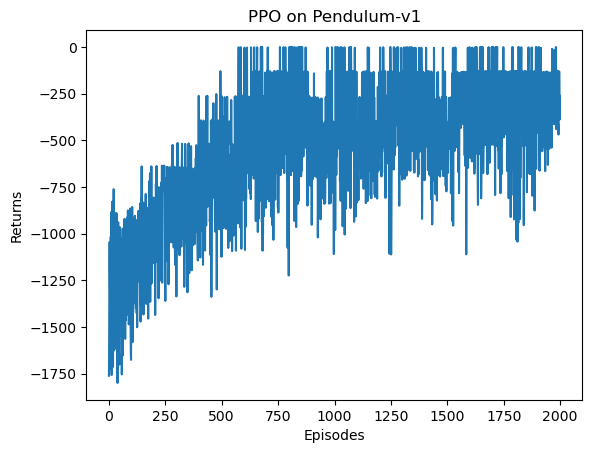

In [5]:
episode_list = list(range(len(return_list)))
plt.plot(episode_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()

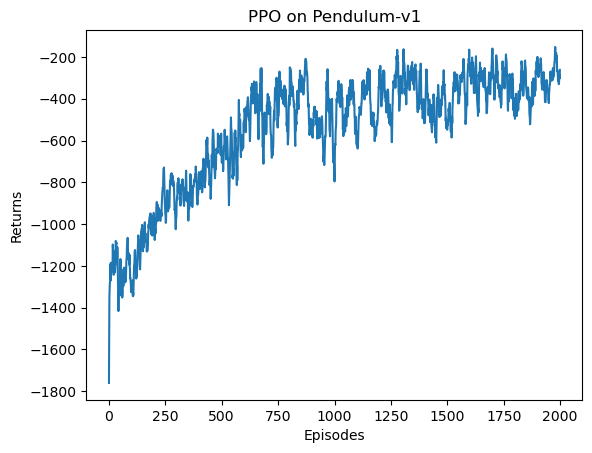

In [6]:
moving_return = rl_utils.moving_average(return_list, 9)
plt.plot(episode_list, moving_return)
plt.xlabel("Episodes")
plt.ylabel("Returns")
plt.title("PPO on {}".format(env_name))
plt.show()